## 2.7 선형 방정식 풀이의 양자 가속 (HHL 알고리즘)

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import StatevectorSimulator  # StatevectorSimulator 사용
from qiskit.circuit.library import HGate
from qiskit.visualization import plot_histogram, plot_bloch_multivector
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 행렬 A와 벡터 b 정의
A = np.array([[1, 1], [1, -1]])
b = np.array([1, 0])

In [3]:
# 벡터 b를 정규화해 초기 양자 상태 |b> 준비
b_norm = np.linalg.norm(b)
b_normalized = b / b_norm

In [4]:
# 상태 준비용 양자 회로 생성
n_qubits = 3  # 고윳값 추정 1, 시스템 1, 보조 1
qc = QuantumCircuit(n_qubits)

In [5]:
# 상태 준비 |b>
initial_state = b_normalized
qc.initialize(initial_state, 1)

In [6]:
# 고윳값 추정
qc.h(0)
qc.cp(2 * np.pi / 2, 0, 1)
qc.h(0)

In [7]:
# 제어 유니터리 (단순화를 위해 여기서는 항등 사용; 실제 U로 대체)
qc.cx(0, 2)

In [8]:
# 역수 적용과 회전
theta = 2 * np.arcsin(b_norm)
qc.append(HGate().control(2), [0, 1, 2])

In [9]:
# 측정
qc.measure_all()

In [10]:
# 상태벡터 시뮬레이터 사용
simulator = StatevectorSimulator()

In [11]:
# 양자 회로 트랜스파일 후 실행
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()

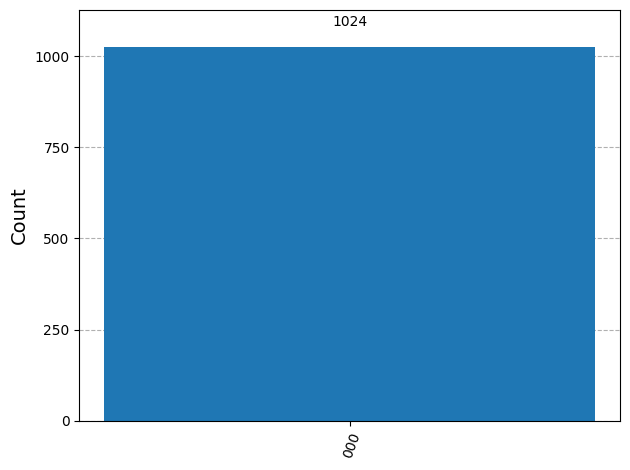

In [12]:
# 결과를 얻어 히스토그램으로 시각화
counts = result.get_counts(compiled_circuit)
plot_histogram(counts)
plt.show()

In [13]:
# 상태벡터를 얻기 위해 회로를 트랜스파일·시뮬레이션
qc.remove_final_measurements()  # 상태벡터 시뮬레이션을 위해 측정 제거
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=1, method='statevector')  # method='statevector' 지정
result = job.result()

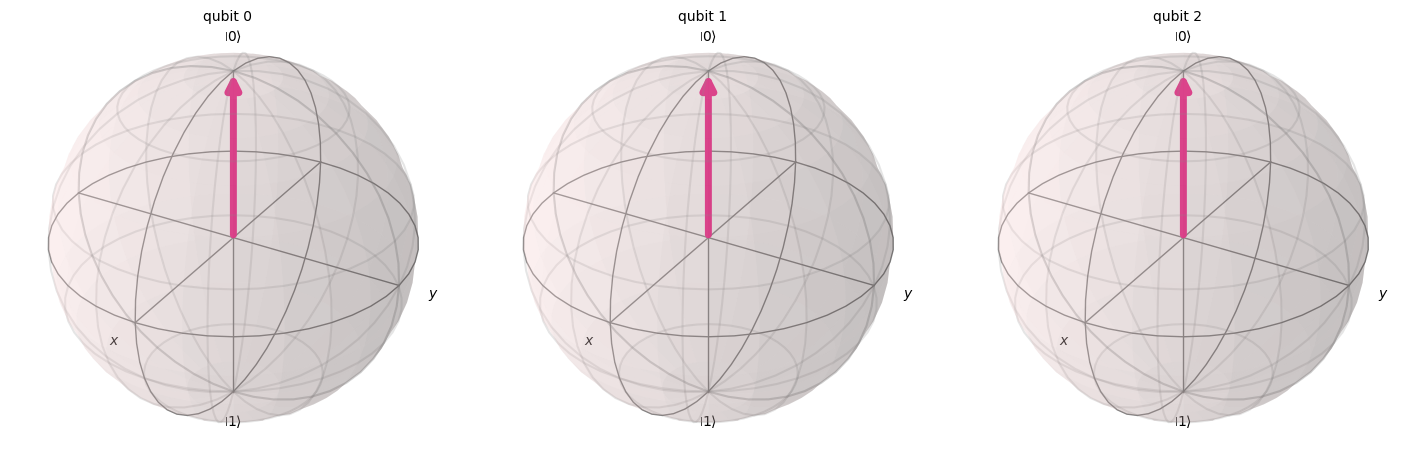

In [14]:
# 결과 상태의 블로흐 벡터 그리기
final_state = result.get_statevector(compiled_circuit)
plot_bloch_multivector(final_state)
plt.show()

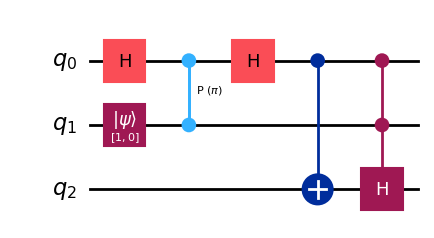

In [15]:
# 양자 회로 그리기
qc.draw('mpl')
plt.show()